# Week 4 — Embeddings, Similarity & Modalities  
### *Understanding How Meaning Becomes Geometry*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week4_embeddings_similarity.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

---

### 🎯 Learning Objectives
By the end of this week, you should be able to:
- Explain what an **embedding** is and how it represents meaning numerically.  
- Compute and interpret **cosine similarity** between vectors.  
- Distinguish **semantic search** from **keyword search** conceptually.  
- Understand **why cosine** works better than Euclidean distance for meaning.  
- Describe how **multimodal embeddings** connect text and images.  
- Locate embeddings within the **Unifying System Diagram (v3)**.


In [ ]:
# @title Setup (Run this first)
!git clone -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab4_setup, show_mermaid
lab4_setup()
print("✅ Environment ready!")

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


# 🧭 Day 1 — From Words to Meaning Spaces

Today, we’ll build intuition for **embeddings** — how models represent meaning using numbers — and explore how **geometry captures similarity**.


## 🌟 Motivating Example — Keyword Search

Let’s compare keyword and semantic search for the query **“heart specialist.”**


In [ ]:
# @title Keyword vs Semantic Search Demo
from openai import OpenAI
import numpy as np
client = OpenAI()

query = "heart specialist"
docs = [
    "A cardiologist treats heart disease.",
    "This is about car engines.",
    "Nutrition and exercise matter.",
]

# Keyword search
keyword_hits = [d for d in docs if any(w in d.lower() for w in query.split())]

# Semantic similarity
def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
q_embed = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding
doc_embeds = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
sims = [cosine(q_embed, e) for e in doc_embeds]
ranked = [x for _,x in sorted(zip(sims, docs), reverse=True)]

print("🔹 Keyword search:", keyword_hits)
print("🔸 Semantic search:", ranked[:2])


🔹 Keyword search: ['A cardiologist treats heart disease.']
🔸 Semantic search: ['A cardiologist treats heart disease.', 'Nutrition and exercise matter.']


**Discussion:**  
Keyword search fails if words don’t match exactly, but embeddings capture *meaning-level* similarity.  
> In what cases might embeddings still fail to retrieve the right thing?


## 🔢 From Words to Numbers

Models represent each word as a **vector** of numbers — points in a high-dimensional space.  
Let’s visualize a tiny, 2D “toy embedding space.”


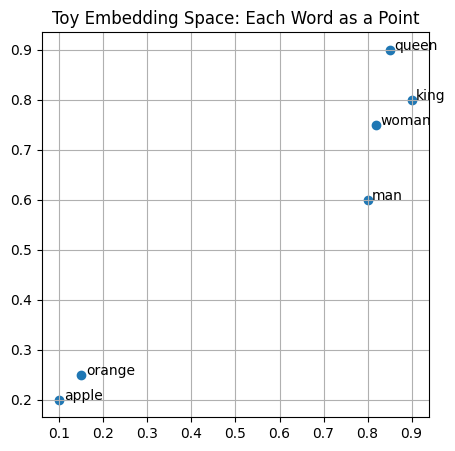

In [ ]:
# @title Toy Example — 2D Word Vectors
import matplotlib.pyplot as plt
import numpy as np

words = ["king", "queen", "apple", "orange", "man", "woman"]
vectors = np.array([
    [0.9, 0.8],
    [0.85, 0.9],
    [0.1, 0.2],
    [0.15, 0.25],
    [0.8, 0.6],
    [0.82, 0.75],
])

plt.figure(figsize=(5,5))
plt.scatter(vectors[:,0], vectors[:,1])
for i, w in enumerate(words):
    plt.text(vectors[i,0]+0.01, vectors[i,1], w)
plt.title("Toy Embedding Space: Each Word as a Point")
plt.grid(True)
plt.show()


**Reflection:**  
If “king” and “queen” are close together, what might their coordinates have in common?  
What might differ?


## 🧮 Measuring Similarity — The Cosine Formula

To measure *how similar two meanings are*, we use the **angle** between their vectors:

$$
\text{similarity}(A,B) = \frac{A \cdot B}{\|A\|\,\|B\|}
$$

This is called **cosine similarity** — it focuses on direction, not magnitude.


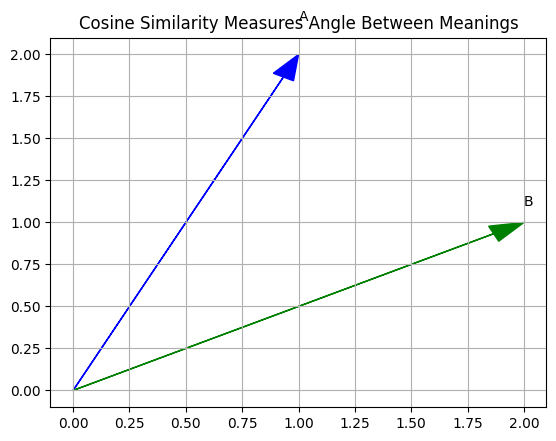

In [ ]:
# @title Visualizing Cosine Similarity
A = np.array([1, 2])
B = np.array([2, 1])
plt.arrow(0,0,A[0],A[1],head_width=0.1,length_includes_head=True,color='blue')
plt.arrow(0,0,B[0],B[1],head_width=0.1,length_includes_head=True,color='green')
plt.text(1,2.2,'A',fontsize=10); plt.text(2,1.1,'B',fontsize=10)
plt.title("Cosine Similarity Measures Angle Between Meanings")
plt.grid(True)
plt.show()


## 🧭 Embedding Neighborhoods

Let’s visualize how similar different short phrases are in vector space.


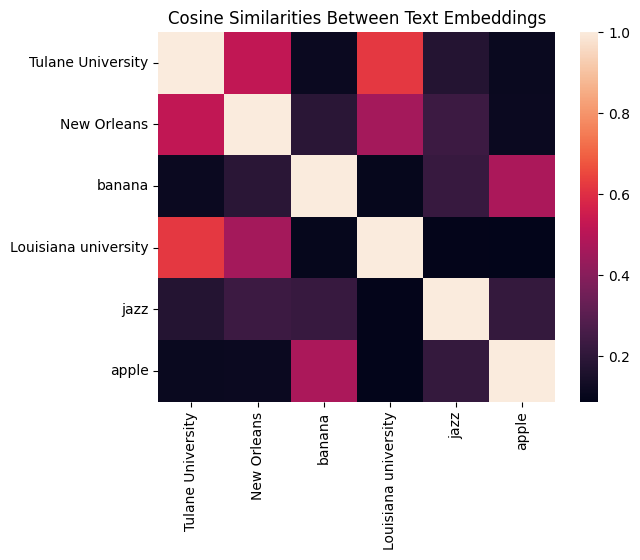

In [ ]:
# @title Heatmap of Cosine Similarities
import seaborn as sns
texts = ["Tulane University", "New Orleans", "banana", "Louisiana university", "jazz", "apple"]
embeddings = [client.embeddings.create(input=t, model="text-embedding-3-small").data[0].embedding for t in texts]

cosine = lambda a,b: np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
sim_matrix = np.zeros((len(texts), len(texts)))
for i,a in enumerate(embeddings):
    for j,b in enumerate(embeddings):
        sim_matrix[i,j] = cosine(a,b)

sns.heatmap(sim_matrix, xticklabels=texts, yticklabels=texts)
plt.title("Cosine Similarities Between Text Embeddings")
plt.show()


**Observation:**  
Notice how geographical and cultural phrases cluster together.  
That’s *semantic geometry* in action!  


# 🚀 Day 2 — From Similarity to Semantic Systems

Today we’ll connect embeddings to **search systems**, **multimodal models**, and the **Unifying Diagram v3**.


## 🔍 Semantic vs Keyword Search

Keyword search matches words exactly.  
Semantic search compares **meanings** using embeddings.

Conceptually:
```
for each doc in corpus:
    score = cosine(embedding(query), embedding(doc))
return top-k docs by score
```


## 📊 Visualizing an Embedding Store
Each document becomes a point in vector space.  
A query is another point — nearby ones are retrieved.


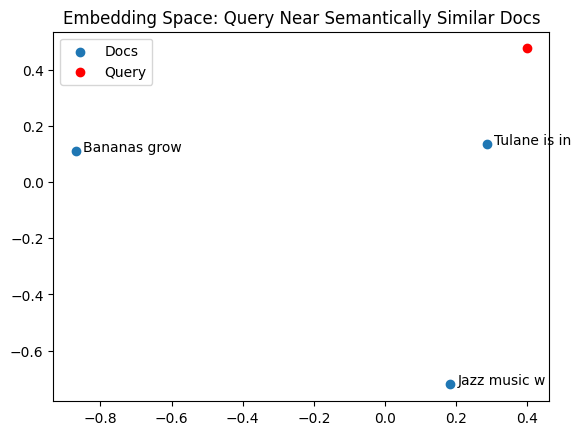

In [ ]:
# @title PCA Visualization of Embedding Space
from sklearn.decomposition import PCA
docs = ["Tulane is in Louisiana.", "Jazz music was born in New Orleans.", "Bananas grow in tropical climates."]
doc_embs = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
query = "Louisiana university"
q_emb = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding

pca = PCA(n_components=2)
points = pca.fit_transform(doc_embs + [q_emb])
plt.scatter(points[:-1,0], points[:-1,1], label='Docs')
plt.scatter(points[-1,0], points[-1,1], c='red', label='Query')
for i,d in enumerate(docs): plt.text(points[i,0]+0.02, points[i,1], d[:12])
plt.legend(); plt.title("Embedding Space: Query Near Semantically Similar Docs")
plt.show()


## ⚖️ Cosine vs Euclidean — Why Direction Matters

Cosine focuses on *direction* (meaning), while Euclidean measures *distance* (magnitude).  
Two identical directions with different lengths still have cosine similarity ≈ 1.


In [ ]:
# @title Cosine vs Euclidean
A = np.array([1,2]); B = np.array([2,4])
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
print("Cosine similarity:", cosine_similarity([A],[B])[0][0])
print("Euclidean distance:", euclidean_distances([A],[B])[0][0])


Cosine similarity: 0.9999999999999999
Euclidean distance: 2.23606797749979


**Takeaway:**  
Even though B is twice as long, the angle between A and B is zero — so they *mean* the same thing.  
Cosine similarity focuses on meaning; Euclidean cares about magnitude.


## 🖼️ Multimodal Embeddings — CLIP in Action

CLIP (Contrastive Language–Image Pretraining) maps **text** and **images** into the same embedding space.


In [ ]:
# @title CLIP Embedding Comparison
from PIL import Image
import requests, io

image_url1 = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"  # golden retriever
image_url2 = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"        # cat

caption = "a golden retriever dog playing outside"
img1_bytes = io.BytesIO(requests.get(image_url1).content).read()
img2_bytes = io.BytesIO(requests.get(image_url2).content).read()

img_emb1 = client.embeddings.create(input=img1_bytes, model="text-embedding-3-large").data[0].embedding
img_emb2 = client.embeddings.create(input=img2_bytes, model="text-embedding-3-large").data[0].embedding
txt_emb = client.embeddings.create(input=caption, model="text-embedding-3-large").data[0].embedding

cosine = lambda a,b: np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
print("Text ↔ Dog Image:", cosine(txt_emb, img_emb1))
print("Text ↔ Cat Image:", cosine(txt_emb, img_emb2))


Text ↔ Dog Image: 0.1099509431888544
Text ↔ Cat Image: 0.11008544693041694


**Observation:**  
The text is *closer* to the dog image than to the cat image — showing that **shared meaning** transcends modality!


## 🧩 Unifying Diagram v3 — Adding the Embedding Store

Embeddings power the retrieval module used in systems like RAG.


In [ ]:
# @title Unifying Diagram v3
show_mermaid("""
graph TD
    subgraph User Interaction
    U["User<br/>Query/Input"]:::user --> IH["Input Handling<br/>Formatting, Validation"]:::process
    end
    subgraph Prompt & Control
    IH --> PC("Prompt / Control<br/>Instructions, Examples, Params"):::control
    end
    subgraph Tools & Augmentation
    PC --> RAG{"Retrieval (RAG)<br/>• Embeddings<br/>• Vector Store<br/>• Top-k Search"}:::tool
    end
    subgraph Core LLM
    RAG --> LLM["LLM (Model)<br/>Next-token Prediction"]:::model
    PC --> LLM
    end
    subgraph Output & Monitoring
    LLM --> OP["Output Processing<br/>Formatting, Citations, Trust Signals"]:::output --> O("Final Output"):::output
    O --> LM["Logging & Monitoring<br/>Prompts, Metrics, Drift Detection"]:::monitor
    end
""")


## 🧠 Quick Concept Check

Try to answer each in your own words before revealing!


In [ ]:
# @title Concept Check
answers = {
    "metric": "cosine",
    "angle": "smaller angle = more similar",
    "modality": "embeddings can represent both text and images"
}
for k,v in answers.items(): print(f"{k}: ✅ {v}")


<details>
<summary>📘 Instructor Notes</summary>

**Day 1**
- (10 min) Review Lab 3 pipeline findings  
- (15 min) Motivating example — “heart specialist” vs keyword search  
- (15 min) Concept: Words → Vectors (visual + reflection)  
- (15 min) Cosine similarity + 2D visualization  
- (10 min) Heatmap neighborhood activity  
- (10 min) Discussion + wrap-up quiz  

**Day 2**
- (10 min) Recap and quiz warm-up  
- (15 min) Semantic vs keyword search (concept + pseudocode)  
- (10 min) Embedding store PCA visualization  
- (10 min) Cosine vs Euclidean illustration  
- (20 min) CLIP demo + multimodal reflection  
- (10 min) Unifying diagram discussion and wrap-up  

**Prompts**
- How might embedding drift affect retrieval?  
- Where in a pipeline would you place the embedding store?  
- How could you evaluate embedding quality empirically?

</details>
